# **Módulo 3: Modelos de Regressão Fundamentais**

---





Neste notebook, você irá trabalhar com o dataset já pré-processado no Módulo 2. Isso significa que todas as etapas de limpeza, imputação, codificação e padronização já foram concluídas — permitindo que você se concentre exclusivamente na **modelagem**.

Aqui, exploraremos os principais modelos de regressão apresentados no módulo:

- Regressão Linear  
- Regressão Polinomial  
- Ridge  
- Lasso  

O objetivo é treinar esses modelos, comparar seus desempenhos e observar como parâmetros como **α** influenciam o ajuste e a generalização.


Quando estiver pronto(a), execute a primeira célula para carregar o dataset e iniciar a modelagem.


## **Configuração Inicial e Carregamento de Dados**

Assim como no módulo anterior, começamos importando as bibliotecas e carregando nossos dados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [ ]:
url = "https://raw.githubusercontent.com/TreinamentoICCInatel/Curso_Regressao_na_Pratica/refs/heads/main/Arquivos/housing_tratado.csv"
housing = pd.read_csv(url)
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,median_house_value
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,0.0,0.0,0.0,1.0,0.0,452600.0
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,0.0,0.0,0.0,1.0,0.0,358500.0
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,0.0,0.0,0.0,1.0,0.0,352100.0
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,0.0,0.0,0.0,1.0,0.0,341300.0
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,0.0,0.0,0.0,1.0,0.0,342200.0


## **Separação entre Treino e Teste**

Como visto na teoria, se avaliarmos o modelo com os mesmos dados usados para treiná-lo, teremos uma visão otimista e irreal (Overfitting). Precisamos separar os dados para simular o desempenho no "mundo real".

**Conceito:**


*   **Treino (70-80%):** Onde o modelo ajusta os parâmetros $\beta$.
*   **Teste (20-30%):** Dados "novos" usados apenas para validar a performance.



O primeiro passo é **selecionar a váriavel alvo** e separar o resto

In [ ]:
# Definindo Y (variável alvo) e X (variáveis explicativas)
Y = housing['median_house_value']
X = housing.drop('median_house_value', axis=1)

Esse trecho de código irá dividir o conjunto de dados em duas partes: **treino** e **teste**.  
A maior parte dos dados será usada para treinar o modelo, enquanto a parte menor será utilizada para avaliar seu desempenho posteriormente.

Após a divisão, o código exibirá quantas amostras ficaram em cada conjunto, permitindo visualizar o tamanho do treino e do teste.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 16512 amostras
Tamanho do Teste: 4128 amostras


## **Regressão Linear Múltipla**

Esse trecho de código treina um modelo de **Regressão Linear** usando os dados de treino (`X_train` e `y_train`).  
Depois, o modelo é utilizado para **prever** os valores de saída com base nos dados de teste (`X_test`), gerando `y_pred_linear`.



In [ ]:
from sklearn.linear_model import LinearRegression

# Instanciando e treinando o modelo
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Realizando previsões nos dados de teste
y_pred_linear = linear_model.predict(X_test)

Em seguida, estamos criando um **gráfico de dispersão** que compara os valores **reais** com os **previstos** pelo modelo.  
Cada ponto representa uma previsão, enquanto a linha tracejada indica onde os valores estariam se o modelo acertasse perfeitamente.  
Esse gráfico ajuda a visualizar o quão próximas as previsões estão dos valores reais.


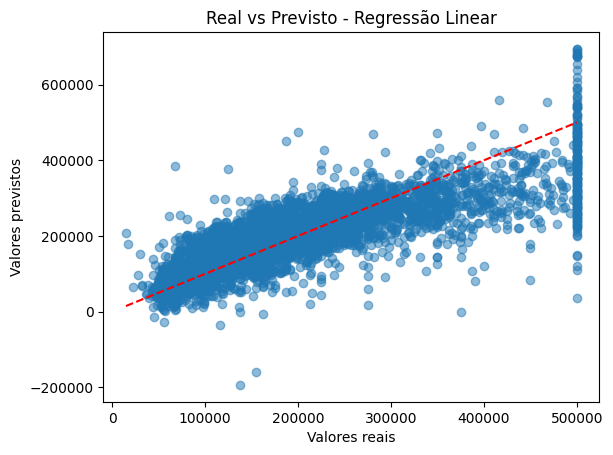

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_linear, alpha = 0.5)
plt.xlabel("Valores reais")
plt.ylabel("Valores previstos")
plt.title("Real vs Previsto - Regressão Linear")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

### **Interpretando os Parâmetros (Intercepto e Coeficientes)**

Conforme vimos nos slides, o LinearRegression calcula os parâmetros que minimizam o erro do modelo. Vamos analisá-los:

- **Intercepto (β₀):** representa o “ponto de partida” da previsão.
- **Coeficientes (βₙ):** indicam o impacto de cada variável sobre o valor previsto.

A seguir, exibimos o intercepto e organizamos os coeficientes associados a cada feature usada no treinamento.  
Eles permitem identificar quais variáveis exercem maior influência positiva ou negativa na previsão.



In [ ]:
print(f"Intercepto (Beta 0): {linear_model.intercept_:.4f}")

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': linear_model.coef_
}).sort_values(by='Coeficiente', ascending=False)

display(coef_df)


Intercepto (Beta 0): 238295.2646


,Feature,Coeficiente
10,ocean_proximity_ISLAND,117198.489753
7,median_income,74991.698606
4,total_bedrooms,43107.993243
6,households,18448.016131
2,housing_median_age,13871.277832
3,total_rooms,-13136.290362
12,ocean_proximity_NEAR OCEAN,-15495.442789
8,ocean_proximity_<1H OCEAN,-18926.582862
11,ocean_proximity_NEAR BAY,-24063.225079
5,population,-43228.323370


**Por exemplo:**

- O coeficiente de `total_bedrooms` é positivo, indicando que, mantendo as demais variáveis constantes, um maior número de quartos aumenta o valor previsto.
- O coeficiente de `latitude` é negativo, mostrando que, quanto maior a latitude (ou seja, mais ao norte), menor tende a ser o preço neste conjunto de dados.


## **Regressão Polinomial e Overfitting**

Muitas relações no mundo real não são retas. A Regressão Polinomial permite ajustar curvas transformando as variáveis (elevando ao quadrado, cubo, etc.).

Atenção: Quanto maior o degree (grau), mais o modelo se ajusta aos dados de treino, mas aumenta o risco de Overfitting (aprender o ruído em vez do padrão).

Nesse trecho, aplicamos Regressão Polinomial usando apenas a variável `median_income` para visualizar como a curva se ajusta aos dados.

Primeiro, transformamos essa variável para incluir termos polinomiais de até **grau 3**, criando automaticamente as versões elevadas ao quadrado e ao cubo. Em seguida, treinamos um modelo de regressão linear sobre esses novos termos — o que, na prática, gera uma regressão polinomial.

Esse processo permite capturar relações mais curvas e complexas entre renda média e valor das casas.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Vamos pegar apenas uma variável para visualizar a curva
X_poly_example = housing[['median_income']].values
y_poly_example = housing['median_house_value'].values

# 1. Transformar os dados para grau 3 (Cria termos cúbicos)
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X_poly_example)

# 2. Treinar a regressão linear nos dados transformados
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y_poly_example)



LinearRegression()

Aqui geramos um gráfico apenas para ilustrar como a regressão polinomial se ajusta aos dados.  
Primeiro, plotamos os pontos reais da relação entre `median_income` e `median_house_value`.  
Em seguida, criamos um intervalo contínuo de valores de renda e usamos o modelo polinomial treinado para prever os preços correspondentes, desenhando assim a curva ajustada.  

Esse gráfico ajuda a visualizar o comportamento não linear capturado pelo modelo polinomial.


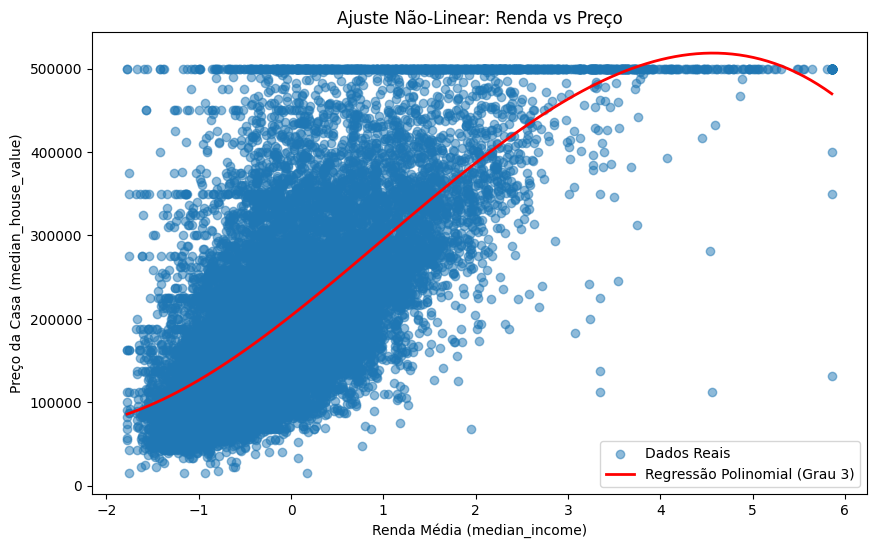

In [ ]:
# Visualização (Apenas ilustrativa para entender a curva)
plt.figure(figsize=(10, 6))
plt.scatter(X_poly_example, y_poly_example, label='Dados Reais', alpha = 0.5)

# Criando linha da curva
X_range = np.linspace(X_poly_example.min(), X_poly_example.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_range_pred = poly_reg.predict(X_range_poly)

plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Regressão Polinomial (Grau 3)')
plt.xlabel('Renda Média (median_income)')
plt.ylabel('Preço da Casa (median_house_value)')
plt.legend()
plt.title('Ajuste Não-Linear: Renda vs Preço')
plt.show()

## **Regularização: Ridge e Lasso**

Para combater o **Overfitting** e a instabilidade causada por coeficientes muito grandes ou variáveis correlacionadas, usamos Regularização. Ela adiciona uma **penalidade** à função de custo.

### **Ridge (Penalização L2)**

A penalização do Ridge "encolhe" os coeficientes suavemente, mas nunca zera. Ótimo para reduzir variância quando temos muitas variáveis.

Agora aplicamos a Regressão Ridge, que é uma variação da regressão linear com penalização.  
O parâmetro `alpha` controla a força dessa penalização: quanto maior o valor, mais o modelo é “simplificado”, reduzindo o impacto de coeficientes muito grandes e ajudando a evitar overfitting.

Em seguida, treinamos o modelo com os dados e exibimos o R² tanto no conjunto de treino quanto no de teste para avaliar o desempenho.


In [ ]:
from sklearn.linear_model import Ridge

# Alpha (ou Lambda) é a força da penalização. Quanto maior, mais simples o modelo.
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

print(f"Score R2 (Ridge - Treino): {ridge_model.score(X_train, y_train):.4f}")
print(f"Score R2 (Ridge - Teste): {ridge_model.score(X_test, y_test):.4f}")

Score R2 (Ridge - Treino): 0.6497
Score R2 (Ridge - Teste): 0.6254


O valor de R² é uma métrica que indica o quanto o modelo consegue explicar a variabilidade dos dados.  
Embora geralmente apareça entre 0 e 1, o R² também pode ser negativo caso o modelo tenha um desempenho pior do que simplesmente prever a média.

Para interpretar o resultado, comparamos o R² do treino e do teste:  
- Valores próximos indicam boa generalização.  
- Um R² muito maior no treino do que no teste sugere overfitting.  
- Quanto maior o R², melhor o modelo explica os dados.

Essa interpretação será aprofundada no próximo módulo.

### **Lasso (Penalização L1)**

O modelo Lasso aplica uma penalização que pode, além de reduzir a magnitude dos coeficientes, **zerar completamente alguns deles**.  
Isso faz com que o Lasso funcione também como um método de seleção de variáveis.




In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

# Verificando coeficientes zerados
lasso_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente_Ridge': ridge_model.coef_,
    'Coeficiente_Lasso': lasso_model.coef_
})

print("Comparação dos Coeficientes:")
display(lasso_coefs)

Comparação dos Coeficientes:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.263e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


,Feature,Coeficiente_Ridge,Coeficiente_Lasso
0,longitude,-53721.122899,-53769.982990
1,latitude,-54356.623686,-54397.822448
2,housing_median_age,13876.079718,13871.291028
3,total_rooms,-13099.970821,-13136.085587
4,total_bedrooms,43076.372660,43107.902824
5,population,-43218.402031,-43228.269489
6,households,18434.078253,18447.856192
7,median_income,74978.148277,74991.646999
8,ocean_proximity_<1H OCEAN,-14047.319640,16642.182226
9,ocean_proximity_INLAND,-53854.137164,-23144.519574


Na tabela acima comparamos os coeficientes do Ridge e do Lasso:
- O **Ridge** reduz os coeficientes, mas nunca os zera.  
- O **Lasso** pode zerar coeficientes, indicando que o modelo as "descartou" por considerá-las redundantes ou irrelevantes dado o nível de penalização `alpha`.

Assim, conseguimos visualizar quais features o Lasso considera menos relevantes, enquanto o Ridge apenas suaviza seus efeitos.



---


Neste notebook exploramos diferentes abordagens de regressão — Linear, Polinomial, Ridge e Lasso — para entender como cada uma modela relações nos dados e lida com problemas como complexidade e overfitting.  
Vimos como interpretar coeficientes, como a regularização influencia o modelo e como cada técnica traz vantagens específicas dependendo do cenário.

Esses conceitos formam a base para modelagens mais robustas e servirão de fundamento para assuntos que aprofundaremos no próximo módulo, onde detalharemos melhor métricas como o R² e técnicas avançadas de avaliação de modelos.